In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import cns.data_utils as cdu
import cns

plt.rcParams.update({'font.size': 12})
color_map = plt.cm.get_cmap('tab10').colors[:10]

C:\Users\adams\AppData\Local\Temp\ipykernel_65028\3382518152.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [3]:
samples_df, cns_df = cdu.main_load("3MB")
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
datasets = samples_df["source"].unique()

In [4]:
lusc_sel = cns.select_cns_by_type(cns_df, samples_df, "LUSC")
lusc_var = cns.calc_chrom_var(lusc_sel, "total_cn")
luad_sel = cns.select_cns_by_type(cns_df, samples_df, "LUAD")
luad_var = cns.calc_chrom_var(luad_sel, "total_cn").sort_values(ascending=False)

In [5]:
# Merge luad_var and lusc_var into a single DataFrame for comparison
var_df = pd.DataFrame({
    'LUAD_var': luad_var,
    'LUSC_var': lusc_var
})
var_df["merge_var"] = (var_df["LUAD_var"] + var_df["LUSC_var"]) / 2
var_df.sort_values("merge_var", ascending=False, inplace=True)
var_df

,LUAD_var,LUSC_var,merge_var
chrom,,,
chr3,1.587211,7.627193,4.607202
chr8,5.687437,3.349523,4.518480
chr5,3.098554,3.731222,3.414888
chr7,3.819167,2.628475,3.223821
chr20,2.763069,2.963309,2.863189
chr19,2.711049,2.628021,2.669535
chr14,3.005226,2.145731,2.575479
chr12,3.071110,2.022799,2.546955
chr18,2.291909,1.912032,2.101970


(<Figure size 1440.52x400 with 1 Axes>,
 <Axes: xlabel='position on the linear genome', ylabel='total_cn'>)

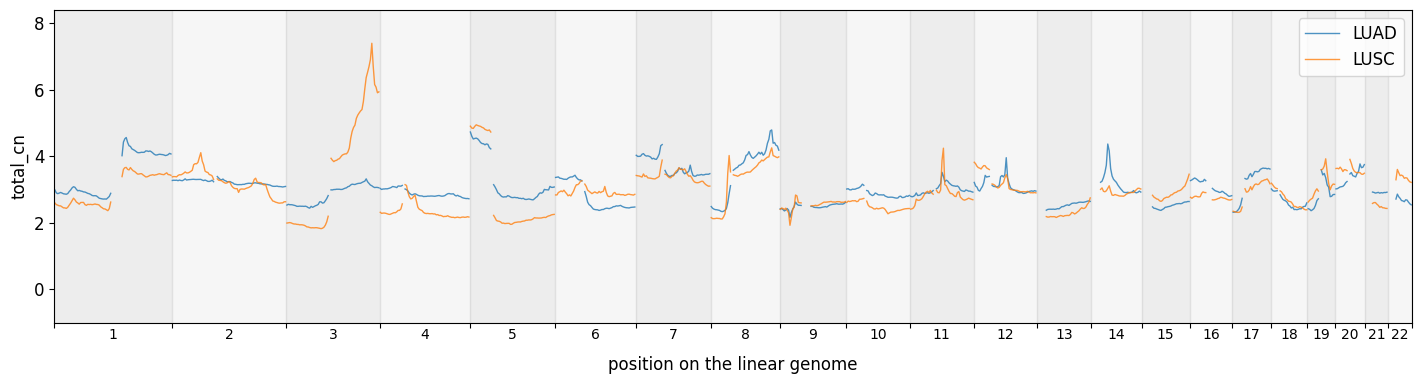

In [6]:
lusc_all = cns.group_samples(lusc_sel, group_name="LUSC")
luad_all = cns.group_samples(luad_sel, group_name="LUAD")
both_all = pd.concat([lusc_all, luad_all], axis=0)
cns.fig_lines(both_all, "total_cn", colors=color_map[:2])

In [7]:
wd_all = cns.calc_chrom_distances(both_all, "total_cn")
wd_all.sort_values(ascending=False)

chr3     0.334866
chr5     0.188635
chr6     0.128727
chr14    0.085513
chr20    0.076276
chr4     0.068388
chr2     0.067010
chr12    0.066429
chr7     0.064690
chr8     0.050032
chr11    0.043741
chr16    0.043370
chr19    0.036967
chr15    0.027604
chr17    0.026823
chr13    0.026536
chr1     0.024983
chr18    0.022769
chr21    0.022627
chr9     0.021579
chr10    0.015070
chr22    0.010605
dtype: float64

In [8]:
def first_name(name):
    return name.split("_")[0]

In [9]:
datasets = ["PCAWG", "TRACERx", "TCGA_hg19"]
luad_dict = { f'{first_name(k)} LUAD': cns.select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { f'{first_name(k)} LUSC': cns.select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
all_dict = luad_dict | lusc_dict
means_single = pd.concat([cns.add_total_cn(cns.group_samples(v, group_name=k)) for k, v in all_dict.items()])

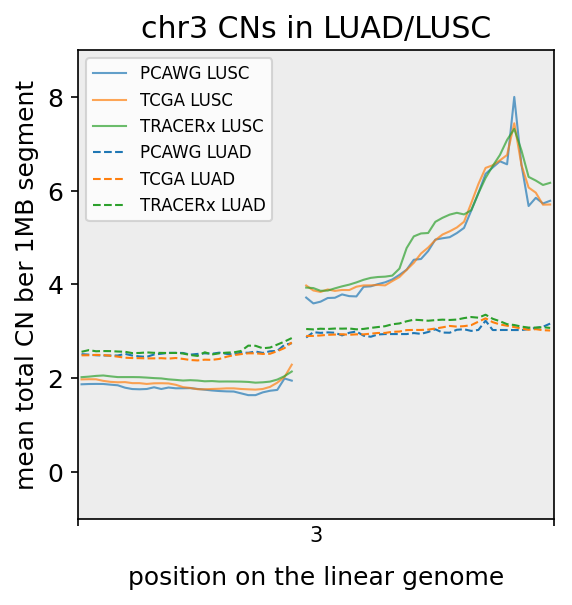

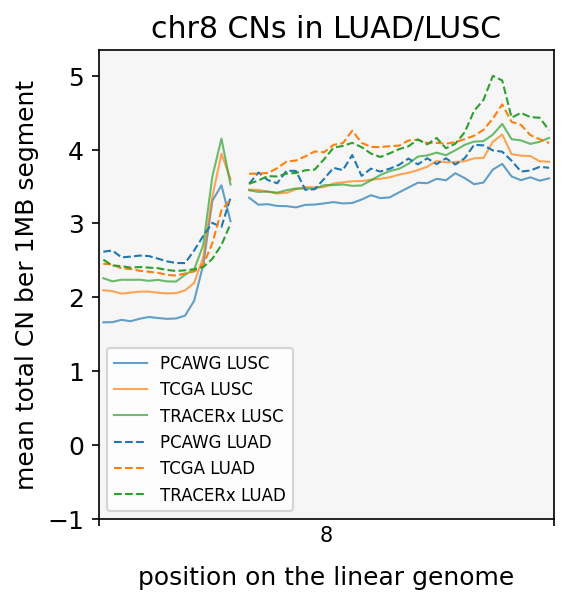

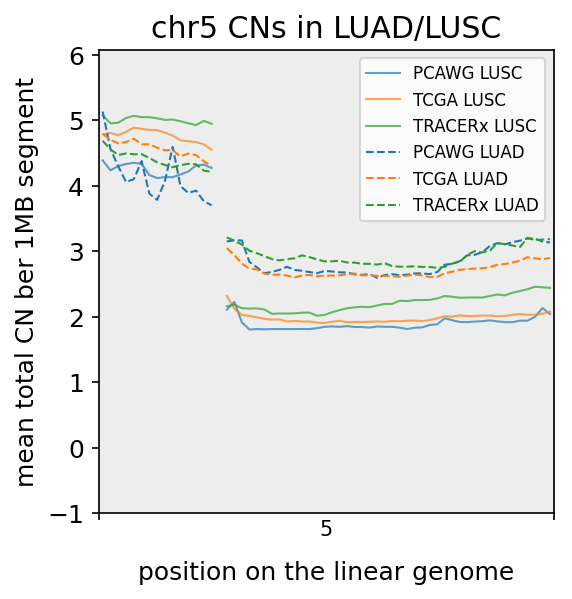

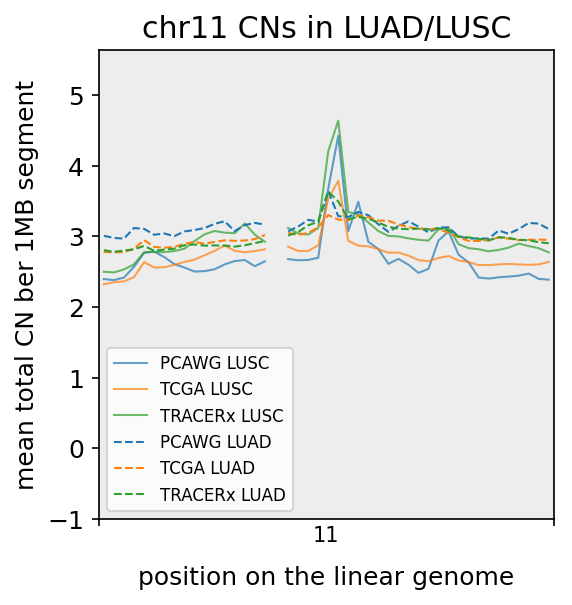

In [10]:
chroms = ["chr3", "chr8", "chr5", "chr11"]
for chrom in chroms:
	lusc_means = means_single.query(f"chrom == '{chrom}' and sample_id.str.endswith('LUSC')", engine='python')
	fig, ax = cns.fig_lines(lusc_means, cn_columns="total_cn", colors=color_map[:3])
	lines = list(ax.lines)

	luad_means = means_single.query(f"chrom == '{chrom}' and sample_id.str.endswith('LUAD')", engine='python')
	for i, (name, group) in enumerate(luad_means.groupby("sample_id")):
		cns.plot_lines(ax, group, cn_column="total_cn", color=color_map[i], label=name)

	for line in ax.lines:
		line.set_linestyle("--")
	for line in lines:
		line.set_linestyle("-")

	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title(f"{chrom} CNs in LUAD/LUSC")
	ax.legend(fontsize=8)
	fig.set_dpi(150)
	cdu.save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [11]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
datasets = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
correlations = []
for ctype in ["LUAD", "LUSC"]:
    for i in datasets:
        for j in datasets:
            first = f"{i} {ctype}"
            second = f"{j} {ctype}"
            corr = means_single.query(f"sample_id == '{i} {ctype}'")["total_cn"].corr(
                means_single.query(f"sample_id == '{j} {ctype}'")["total_cn"], method="pearson"
            )
            correlations.append((i, j, ctype, corr))

corr_df = pd.DataFrame(correlations, columns=["first", "second", "type", "corr"])
for ctype in ["LUAD", "LUSC"]:
    filtered_df = corr_df[corr_df['type'] == ctype]
    pivot_df = filtered_df.pivot(index='first', columns='second', values='corr')
    print(f"Correlation matrix for {ctype}:")
    print(pivot_df)

Correlations on 1 Mb segments between datasets
Correlation matrix for LUAD:
second      PCAWG      TCGA   TRACERx
first                                
PCAWG    1.000000  0.830458  0.835271
TCGA     0.830458  1.000000  0.978860
TRACERx  0.835271  0.978860  1.000000
Correlation matrix for LUSC:
second      PCAWG      TCGA   TRACERx
first                                
PCAWG    1.000000  0.971617  0.968666
TCGA     0.971617  1.000000  0.987291
TRACERx  0.968666  0.987291  1.000000


In [12]:
_, cosmic_df = cdu.main_load("COSMIC")
cosmic_group = cns.group_samples(cosmic_df)

In [13]:
cosmic_lusc_group = cns.add_total_cn(cns.group_samples(cns.select_cns_by_type(cosmic_df, samples_df, "LUSC"), group_name="COSMIC LUSC"))
cosmic_luad_group = cns.add_total_cn(cns.group_samples(cns.select_cns_by_type(cosmic_df, samples_df, "LUAD"), group_name="COSMIC LUAD"))
cosmic_both = pd.concat([cosmic_lusc_group, cosmic_luad_group])

In [14]:
# Plot the top attributions
cosmic_lusc_group.sort_values("total_cn", ascending=False).head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
481,chr3,178865901,178957881,PIK3CA,5.136358,1.793944,COSMIC LUSC,6.930302
480,chr3,176737142,176915261,TBL1XR1,4.979333,1.795855,COSMIC LUSC,6.775188
483,chr3,185000728,185206885,MAP3K13,4.852308,1.730944,COSMIC LUSC,6.583252
484,chr3,185361526,185542844,IGF2BP2,4.738830,1.718823,COSMIC LUSC,6.457654


In [15]:
# Plot the neighbours of SOX2
cosmic_lusc_group.query("chrom == 'chr3'").query("start > 175000000").head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
480,chr3,176737142,176915261,TBL1XR1,4.979333,1.795855,COSMIC LUSC,6.775188
481,chr3,178865901,178957881,PIK3CA,5.136358,1.793944,COSMIC LUSC,6.930302
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
483,chr3,185000728,185206885,MAP3K13,4.852308,1.730944,COSMIC LUSC,6.583252
484,chr3,185361526,185542844,IGF2BP2,4.738830,1.718823,COSMIC LUSC,6.457654


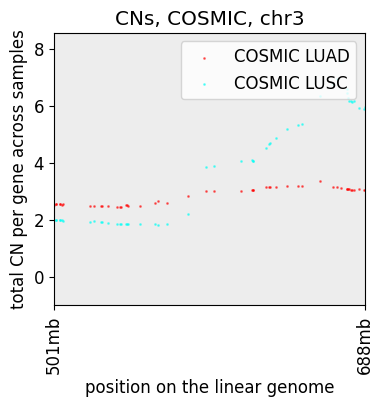

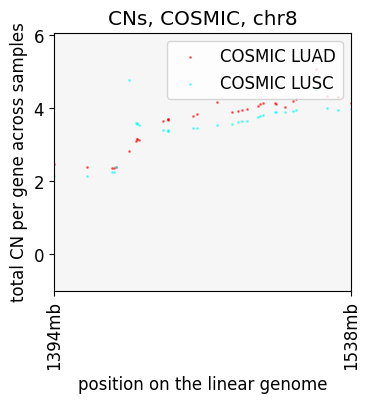

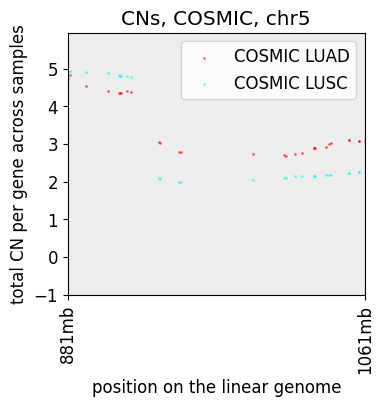

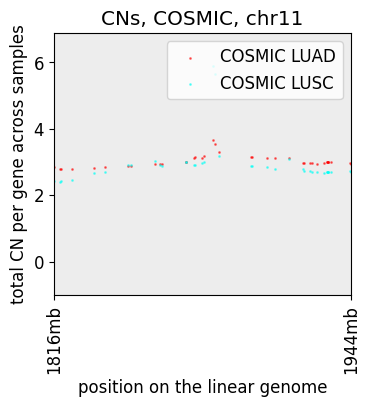

In [16]:
for chrom in chroms:
    fig, ax = cns.fig_dots(cosmic_both.query(f'chrom == "{chrom}"'), cn_columns="total_cn")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"CNs, COSMIC, {chrom}")
    cdu.save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

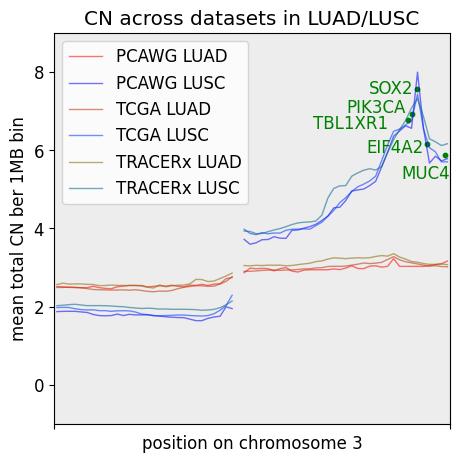

In [17]:
from cns import hg19
colors = ["#FF0000", "#0000FF", "#BB3300", "#0033FF", "#886600", "#006688"]
fig, ax = cns.fig_lines(means_single.query("chrom == 'chr3'"), cn_columns="total_cn", colors=colors)
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
fig.set_size_inches(5, 5) 
# erase x labels

offsets = {
    'EIF4A2': (-.2, -.1),
    'SOX2': (-.2, 0),
    'TBL1XR1': (-1, -.1),
    'PIK3CA': (-.3, .15),
    "MUC4": (.25, -.5)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = cns.calc_mid(row) + hg19.chr_starts["chr3"]
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name, color="green", size=12, ha='right', va='center')

ax.set_xticklabels([], minor=True)
ax.set_xlabel("position on chromosome 3", labelpad=-12)

cdu.save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")

Mean LUSC CN: 5.640136705763451


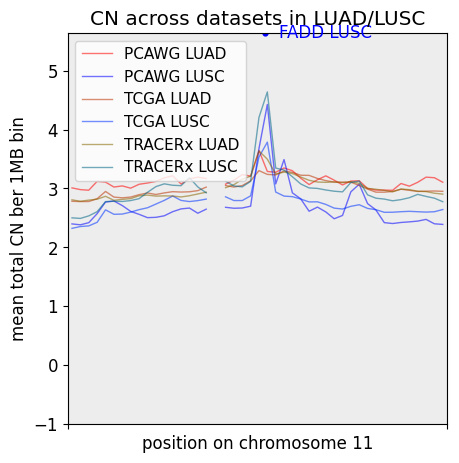

In [18]:
from cns import hg19
colors = ["#FF0000", "#0000FF", "#BB3300", "#0033FF", "#886600", "#006688"]
fig, ax = cns.fig_lines(means_single.query("chrom == 'chr11'"), cn_columns="total_cn", colors=colors)
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left', fontsize=11)
fig.set_size_inches(5, 5) 
# erase x labels

offsets = {
    "FADD": (.5, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['FADD']:
        mid = cns.calc_mid(row) + hg19.chr_starts["chr11"]
        plt.scatter(mid, row['total_cn'], color='blue', s=12)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name + " LUSC", color="blue", size=12, ha='left', va='center')
        print("Mean LUSC CN:", row['total_cn'],)

ax.set_xticklabels([], minor=True)
ax.set_xlabel("position on chromosome 11", labelpad=-12)

cdu.save_cns_fig(f"fig_COSMIC_lines_IG_att_chr11")